### Extract spike timeseries aligned to specific event for every unit

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
from notebooks.imports import *
import scipy.io
from config import dir_config, ephys_config
from src.utils import ephys_utils
import pickle
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm


compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [2]:
session_metadata = pd.read_csv(Path(processed_dir, "sessions_metadata.csv"))
session_to_exclude = ["210210_GP_JP","241209_GP_TZ"]
session_metadata = session_metadata[~session_metadata["session_id"].isin(session_to_exclude)]

neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"))
neuron_metadata = neuron_metadata[~neuron_metadata["session_id"].isin(session_to_exclude)]

with open(Path(processed_dir, "glm_hmm_masked_final.pkl"), "rb") as f:
	glm_hmm = pickle.load(f)

with open(Path(processed_dir, f'ephys_neuron_wise.pkl'), 'rb') as f:
    ephys = pickle.load(f)

In [3]:
data = glm_hmm["data"].copy()
n_trial_back = 1
for session_id in session_metadata["session_id"]:
    trial_data = pd.read_csv(Path(compiled_dir, session_id, f"{session_id}_trial.csv"), index_col=None)
    GP_trial_data = trial_data[trial_data.task_type == 1].reset_index(drop=True)
    # Get valid indices based on outcomes
    valid_idx = np.where(GP_trial_data.outcome >= 0)[0]
	# First valid trial considering n_trial_back
    first_trial = valid_idx[n_trial_back - 1] + 1
    reaction_time = np.array(GP_trial_data.reaction_time)[first_trial:]
    data[session_id]["reaction_time"] = reaction_time
    # data[session_id] = data[session_id][data[session_id]["prob_toRF"] != 50]
    if session_metadata["prior_direction"][session_metadata["session_id"] == session_id].values == "awayRF":
        data[session_id]["choices"] = 1 - data[session_id]["choices"]
        data[session_id]["stimulus"] = -data[session_id]["stimulus"]


In [ ]:
# import copy
# high_confidence_threshold = 0.8
# state_occupancy = {}
# data_flipped = copy.deepcopy(data)
# for idx_session, session_id in enumerate(session_metadata["session_id"]):
#     model = glm_hmm["model"]["models"][session_id]
#     choices = data[session_id]["choices"].values.reshape(-1, 1)
#     input = np.array(data[session_id][["normalized_stimulus", "bias", "prev_choice_1", "prev_target_1"]])
#     if data[session_id]["mask"] is None:
#         mask = None
#     else:
#         mask = data[session_id]["mask"]
#     mask = np.ones_like(choices, dtype=bool) if mask is None else mask

#     posterior_probs = model.expected_states(data=choices, input=input, mask=np.array(mask).reshape(-1, 1))[0]
#     biased_idx = (posterior_probs[:, 0] > high_confidence_threshold) & np.array(mask)
#     unbiased_idx = (posterior_probs[:, 1] > high_confidence_threshold) & np.array(mask)
#     state_occupancy[session_id] = {"biased_state_trials": data[session_id]["trial_num"][biased_idx], "unbiased_state_trials": data[session_id]["trial_num"][unbiased_idx]}

#     #flip back to toRF/awayRF for inputs
#     if session_metadata["prior_direction"][session_metadata["session_id"] == session_id].values[0] == "awayRF":
#         data_flipped[session_id]["choices"] = 1 - data[session_id]["choices"]
#         data_flipped[session_id]["stimulus"] = -data[session_id]["stimulus"]
#         data_flipped[session_id]["normalized_stimulus"] = -data[session_id]["normalized_stimulus"]
#         data_flipped[session_id]["prev_choice_1"] = -data[session_id]["prev_choice_1"]
#         data_flipped[session_id]["prev_target_1"] = -data[session_id]["prev_target_1"]

In [ ]:
# biased_state_trial_info = {}
# unbiased_state_trial_info = {}
# for session_id in session_metadata.session_id:
# 	biased_state_trials = state_occupancy[session_id]["biased_state_trials"]
# 	biased_state_trial_info[session_id] = data_flipped[session_id].loc[np.isin(data_flipped[session_id]["trial_num"], biased_state_trials)]
# 	unbiased_state_trials = state_occupancy[session_id]["unbiased_state_trials"]
# 	unbiased_state_trial_info[session_id] = data_flipped[session_id].loc[np.isin(data_flipped[session_id]["trial_num"], unbiased_state_trials)]

In [4]:
def plot_PSTH(neuron_id, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=None,plot_time=True, x_label=True, ylim=None):
    session_id = neuron_metadata.session_id[neuron_metadata.neuron_id == neuron_id].values[0]

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 7))

    for align_idx, (alignment) in enumerate(['cue']):
        conditions = {
            # "coh_0_choice_toRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0, 1),
            "coh_6_choice_toRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0.06, 1, 1),
            "coh_20_choice_toRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0.2, 1, 1),
            "coh_50_choice_toRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0.5, 1, 1),
            # "coh_0_choice_awayRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0, 0),
            "coh_6_choice_awayRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0.06, 0, 1),
            "coh_20_choice_awayRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0.2, 0, 1),
            "coh_50_choice_awayRF_corr": ephys_utils.get_trial_num(trial_info[session_id], 0.5, 0, 1),
        }
        for condition in conditions:
            trials = conditions[condition]
            plot_params = condition_dict[condition]
            color = plot_params["color"][0] if condition.endswith('toRF_corr') else plot_params["color"][1]
            label = condition
            condition_data = ephys_utils.get_neural_data_from_trial_num(ephys[alignment][neuron_id], trials, type="convolved_spike_trains")
            if alignment == "cue":
                # index = np.where(np.isin(trial_info[session_id]["trial_num"], trials))[0]
                # crop at the timepoint where less than 50% nan
                nan_50_timepoints = np.min([np.where(np.mean(np.isnan(condition_data), axis=0) < 0.5)[0][-1], condition_data.shape[1]])
                ax.plot(np.nanmean(condition_data, axis=0)[: nan_50_timepoints], label=label, color=color,linewidth=plot_params['lw'], linestyle=plot_params['ls'])
            # elif alignment == "response":
            #     # crop at the timepoint where less than 50% nan
            #     nan_50_timepoints = np.where(np.mean(np.isnan(condition_data), axis=0) < 0.5)[0][0]
            #     ax[align_idx].plot(np.nanmean(condition_data, axis=0)[nan_50_timepoints:], label=label, color=color, linewidth=plot_params['lw'], linestyle=plot_params['ls'])
            # else:
            #     ax[align_idx].plot(np.nanmean(condition_data, axis=0), label=label, color=color, linewidth=plot_params["lw"], linestyle=plot_params['ls'])

        ax.set_xlim(0, alignment_dict[alignment]["end_time_ms"] - alignment_dict[alignment]["start_time_ms"])
        ylim = ax.get_ylim() if ylim is None else ylim
        ax.vlines(-alignment_dict[alignment]["start_time_ms"], ylim[0], ylim[1], color="black", linestyle="--", linewidth=3)
        # ax.set_title(alignment)
        # if alignment == "response":
        #     ax[align_idx].set_xticks(
        #         np.arange(0, alignment_dict[alignment]["end_time_ms"] - alignment_dict[alignment]["start_time_ms"] + 1, 50), labels=np.arange(alignment_dict[alignment]["start_time_ms"], alignment_dict[alignment]["end_time_ms"] + 1, 50)
        #     )
        # else:
        # ax.set_xticks([])
        if plot_time:
            ax.set_xlabel("Time from GP onset (ms)", fontsize=30)
            ax.set_xticks([0,100,300,500,700,900])
            ax.set_xticklabels([-100,0,200,400,600,800])
            ax.tick_params(axis='x', labelsize=25)
        else:
            ax.set_xticks([])
            ax.spines['bottom'].set_visible(False)
        ax.set_yticks([])
        #     np.arange(0, alignment_dict[alignment]["end_time_ms"] - alignment_dict[alignment]["start_time_ms"] + 1, 100), labels=np.arange(alignment_dict[alignment]["start_time_ms"], alignment_dict[alignment]["end_time_ms"] + 1, 100)
        # )

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)



    # # Get axis limits
    # xlim = ax.get_xlim()
    # ylim = ax.get_ylim()
    # # Scale values
    # scalebar_x = 200   # 100 ms
    # scalebar_y = 20    # 10 spikes/s
    # # Position: bottom-right with dynamic padding
    # padding_x = 0.02 * (xlim[1] - xlim[0])  # 2% of width
    # padding_y = 0.02 * (ylim[1] - ylim[0])  # 2% of height
    # x_start = 150 + xlim[0] + padding_x
    # x_start_time = -150 + xlim[1] - padding_x
    # y_start = ylim[1] - scalebar_y - padding_y
    # y_start_time = ylim[0] + scalebar_y - padding_y

    # scalebar_font = 40

    # # Horizontal bar (time)
    # # if plot_time:
    # #     ax.hlines(y_start_time, x_start_time, x_start_time + scalebar_x, color="black", linewidth=5)
    # #     ax.text(x_start_time + scalebar_x / 2 , y_start_time - padding_y,
    # #             f"{scalebar_x} ms", ha="center", va="top", fontsize=scalebar_font)

    # # Vertical bar (firing rate)
    # ax.vlines(x_start-3*padding_x, y_start, y_start + scalebar_y, color="black", linewidth=5)
    # ax.text(x_start + padding_x, y_start + scalebar_y / 2,
    #         f"{scalebar_y} sp/s", ha="right", va="center", fontsize=scalebar_font, rotation=90)


    plt.tight_layout()
    # ax[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    # fig.suptitle(f"Neuron ID: {neuron_id} | Session ID: {session_id} | Prior: {session_metadata.prior_direction[session_metadata.session_id==session_id].values[0]}", fontsize=16)

In [5]:
included_neurons = [56, 12, 113, 109]
#other coherence for 85

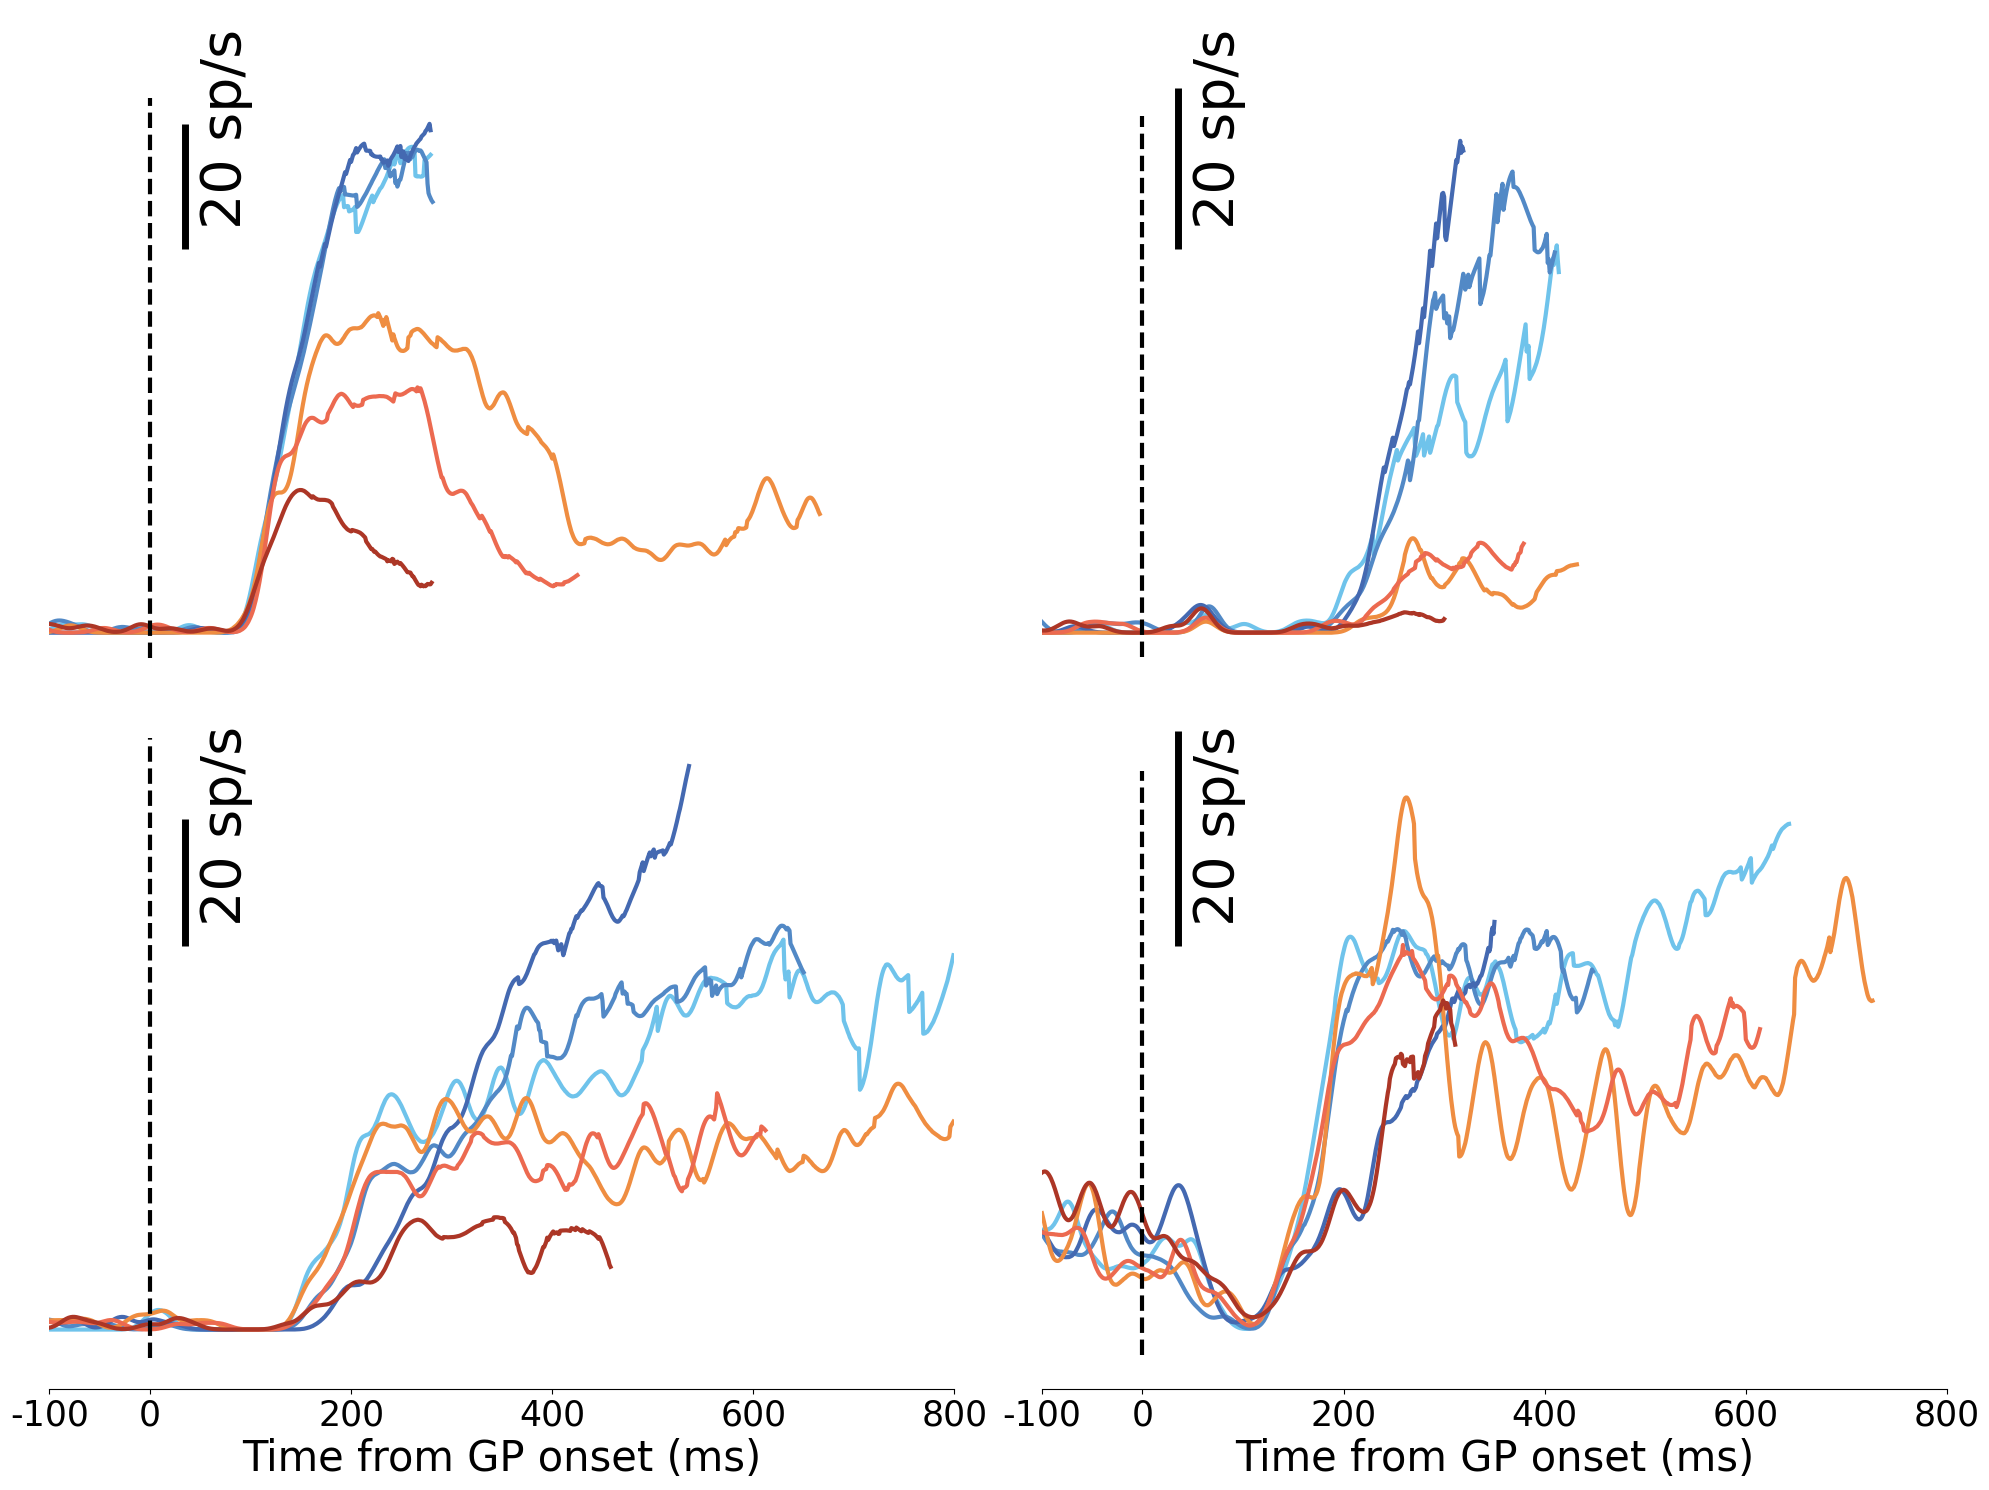

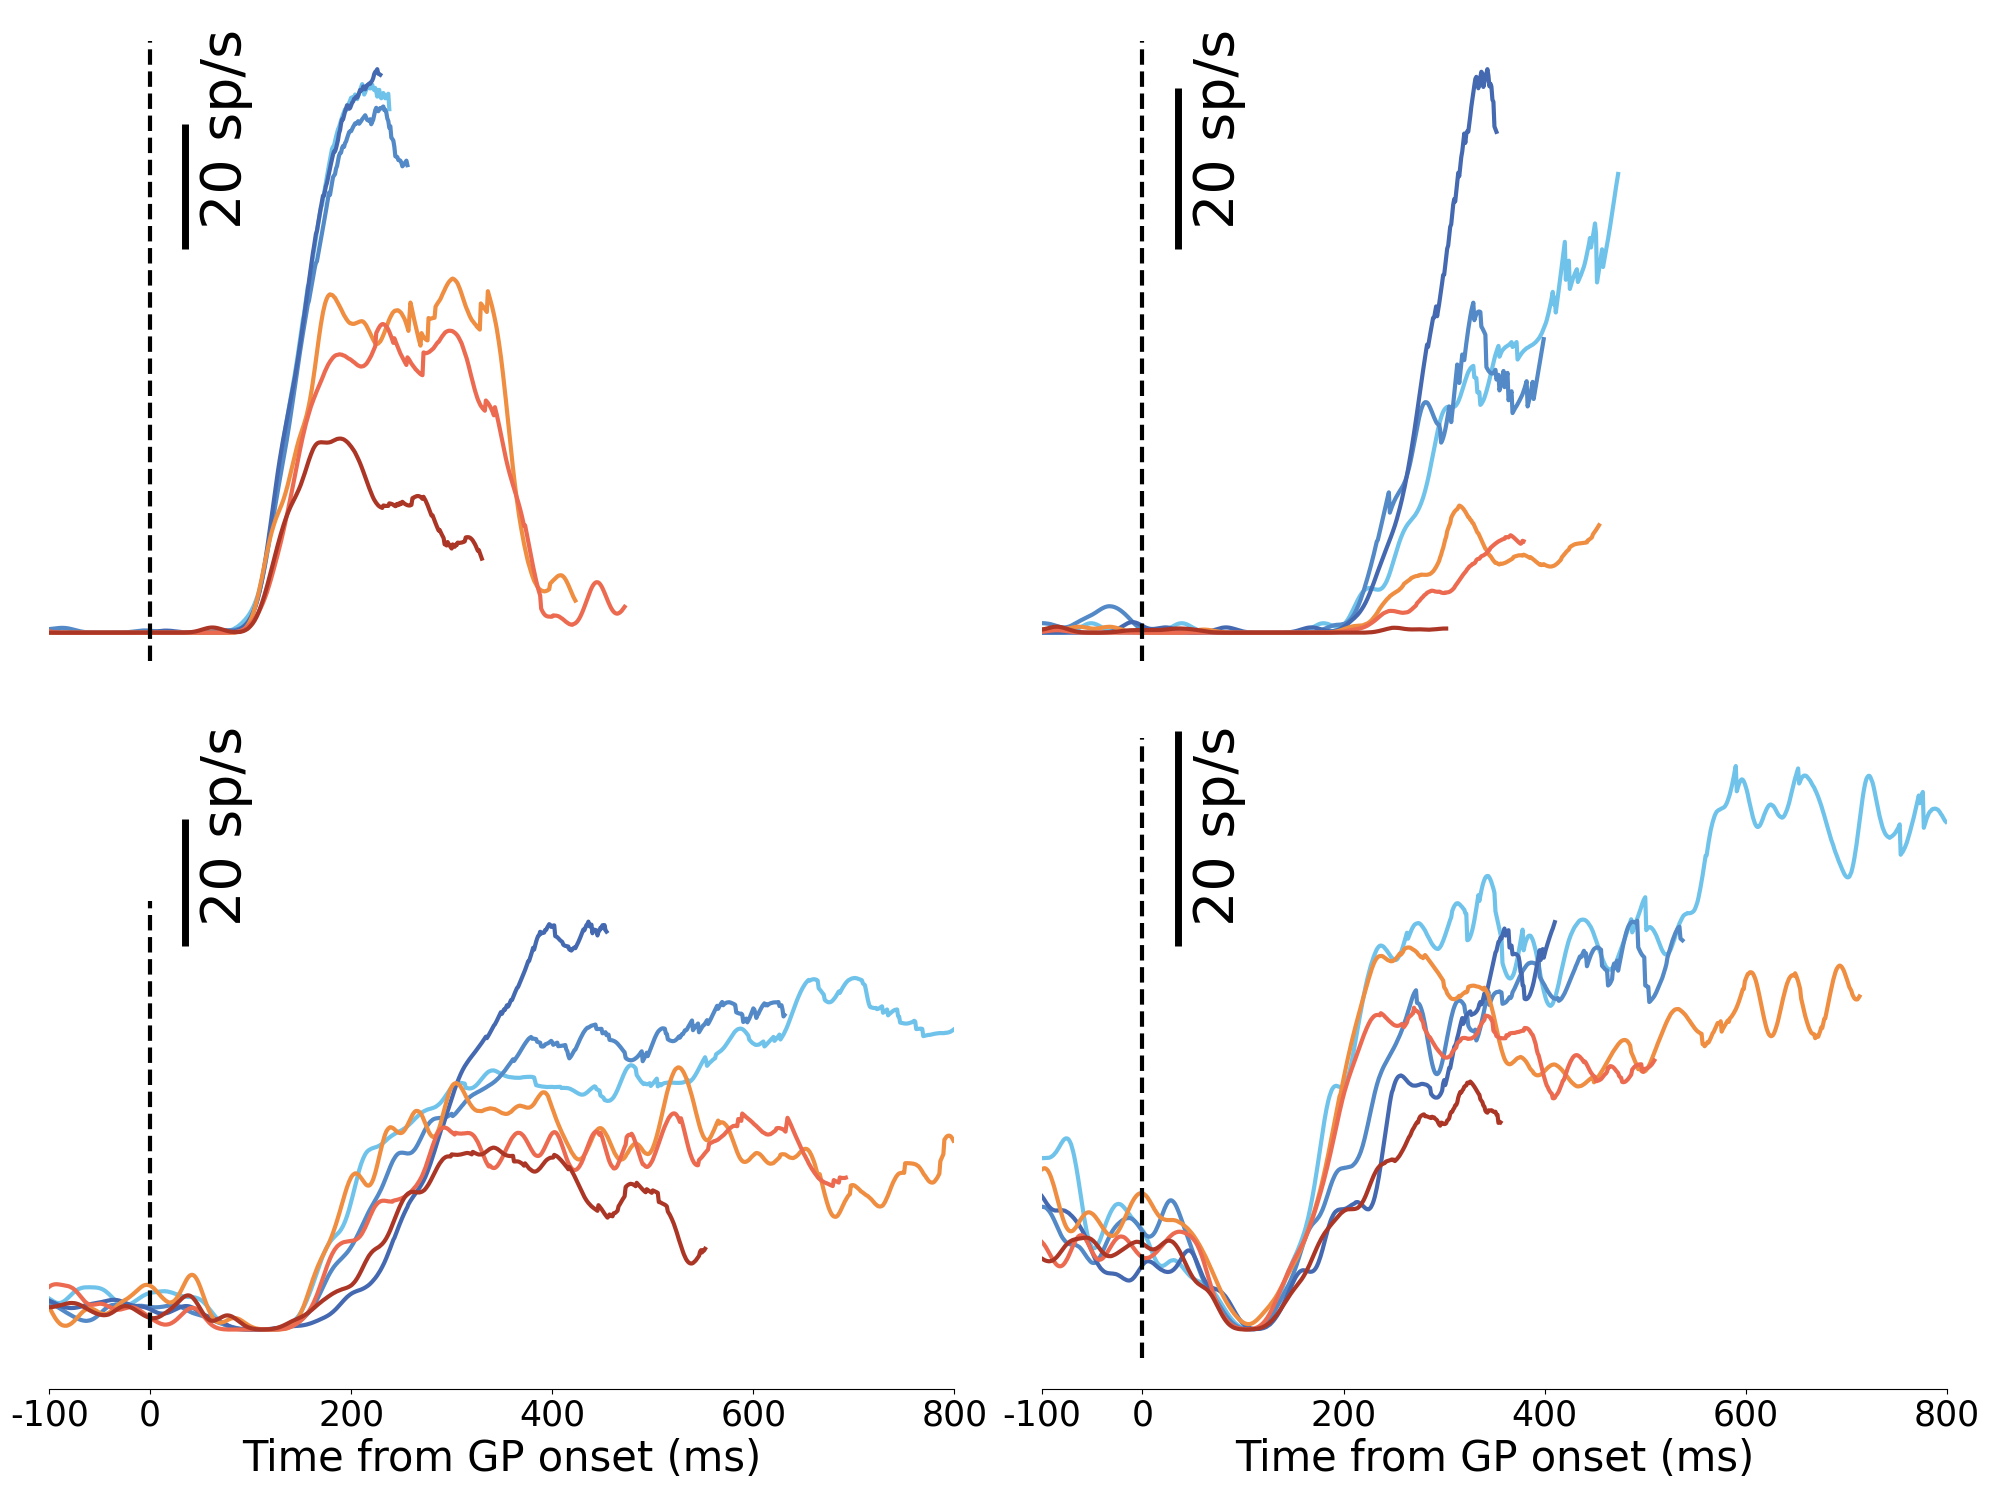

In [31]:
toRF_colors = ["#96D6EC", "#6FC3EB", "#5289C6", "#4469B1"]
unbiased_colors = ["#F2A448", "#EF8D41", "#EC6A50", "#AC3626"]

condition_dict = {
    "coh_0_choice_toRF_corr": {"index": 0, "color": {0:toRF_colors[0], 1: unbiased_colors[0]}, "lw": 3, "ls": '-'},
    "coh_6_choice_toRF_corr": {"index": 1, "color": {0:toRF_colors[1], 1: unbiased_colors[1]}, "lw": 3, "ls": '-'},
    "coh_20_choice_toRF_corr": {"index": 2, "color": {0:toRF_colors[2], 1: unbiased_colors[2]}, "lw": 3, "ls": '-'},
    "coh_50_choice_toRF_corr": {"index": 3, "color": {0:toRF_colors[3], 1: unbiased_colors[3]}, "lw": 3, "ls": '-'},
    "coh_0_choice_awayRF_corr": {"index": 4, "color": {0:toRF_colors[0], 1: unbiased_colors[0]}, "lw": 3, "ls": '-'},
    "coh_6_choice_awayRF_corr": {"index": 5, "color": {0:toRF_colors[1], 1: unbiased_colors[1]}, "lw": 3, "ls": '-'},
    "coh_20_choice_awayRF_corr": {"index": 6, "color": {0:toRF_colors[2], 1: unbiased_colors[2]}, "lw": 3, "ls": '-'},
    "coh_50_choice_awayRF_corr": {"index": 7, "color": {0:toRF_colors[3], 1: unbiased_colors[3]}, "lw": 3, "ls": '-'},
}
from copy import deepcopy

# --- Function to add scale bars ---
def add_scalebar(ax, plot_time=False, scalebar_x=200, scalebar_y=20, fontsize=40):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    padding_x = 0.15 * (xlim[1] - xlim[0])
    padding_y = 0.35 * (ylim[1] - ylim[0])

    # Vertical bar (firing rate)
    x_start = xlim[0] + padding_x
    y_start = ylim[1] - padding_y
    ax.vlines(x_start, y_start, y_start + scalebar_y, color="black", linewidth=5)
    ax.text(x_start + padding_x/2, y_start + padding_y/2,
            f"{scalebar_y} sp/s", ha="right", va="center", fontsize=fontsize, rotation=90)

    # # Horizontal bar (time)
    # if plot_time:
    #     x_start_time = xlim[0] + padding_x
    #     y_start_time = ylim[0] + padding_y
    #     ax.hlines(y_start_time, x_start_time, x_start_time + scalebar_x, color="black", linewidth=5)
    #     ax.text(x_start_time + scalebar_x / 2, y_start_time ,
    #             f"{scalebar_x} ms", ha="center", va="top", fontsize=fontsize)

fig, ax_1 = plt.subplots(2, 2, figsize=(20, 15))
ax_1 = ax_1.flatten()
trial_info = deepcopy(data)
for neuron_idx, neuron in enumerate(included_neurons):
    session_id = neuron_metadata.session_id[neuron_metadata.neuron_id == neuron].values[0]
    trial_info[session_id] = trial_info[session_id][trial_info[session_id]["prob_toRF"] == 50]
    if neuron_idx >=2:
        plot_time=True
    else:
        plot_time=True

    if session_id not in session_metadata["session_id"].values:
        continue
    plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_1[neuron_idx],plot_time=plot_time)
    # add_scalebar(ax_1[neuron_idx], plot_time=plot_time)


shade_colors = ['#b3b3b3', '#7f7f7f', '#4d4d4d', '#000000']
# handles = [
#             plt.Line2D([0], [0], color=shade_colors[3], label="50% coh"),
#             plt.Line2D([0], [0], color=shade_colors[2], label="20% coh"),
#             plt.Line2D([0], [0], color=shade_colors[1], label="6% coh"),
#             # plt.Line2D([0], [0], color=shade_colors[0], label="0% coh"),
#             plt.Line2D([0], [0], color=condition_dict["coh_50_choice_toRF_corr"]["color"][0], label="toRF choice"),
#             plt.Line2D([0], [0], color=condition_dict["coh_50_choice_awayRF_corr"]["color"][1], label="awayRF choice"),
#         ]

# # --- place legend ---
# plt.legend(
#     handles=handles,
#     loc="center right",
#     bbox_to_anchor=(1.1, 1.5),
#     frameon=False,
#     fontsize=25,
# )
plt.savefig("spikedensity_example_equal.svg", format="svg", dpi=300, bbox_inches="tight")


# plt.show()


fig, ax_2 = plt.subplots(2, 2, figsize=(20, 15))
ax_2 = ax_2.flatten()
trial_info = deepcopy(data)
for neuron_idx, neuron in enumerate(included_neurons):
    session_id = neuron_metadata.session_id[neuron_metadata.neuron_id == neuron].values[0]
    trial_info[session_id] = trial_info[session_id][trial_info[session_id]["prob_toRF"] != 50]
    if neuron_idx >=2:
        plot_time=True
    else:
        plot_time=True

    if session_id not in session_metadata["session_id"].values:
        continue
    plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_2[neuron_idx],plot_time=plot_time)
    # add_scalebar(ax_2[neuron_idx], plot_time=plot_time)


# shade_colors = ['#b3b3b3', '#7f7f7f', '#4d4d4d', '#000000']
# handles = [
#             plt.Line2D([0], [0], color=shade_colors[3], label="50% coh"),
#             plt.Line2D([0], [0], color=shade_colors[2], label="20% coh"),
#             plt.Line2D([0], [0], color=shade_colors[1], label="6% coh"),
#             # plt.Line2D([0], [0], color=shade_colors[0], label="0% coh"),
#             plt.Line2D([0], [0], color=condition_dict["coh_50_choice_toRF_corr"]["color"][0], label="toRF choice"),
#             plt.Line2D([0], [0], color=condition_dict["coh_50_choice_awayRF_corr"]["color"][1], label="awayRF choice"),
#         ]
# # --- place legend ---
# plt.legend(
#     handles=handles,
#     loc="center right",
#     bbox_to_anchor=(1.1, 1.5),
#     frameon=False,
#     fontsize=25,
# )

# get max ylim across _1 nd _2
min_ylim = []
max_ylim = []
for i in range(4):
    min_ylim.append(min(ax_1[i].get_ylim()[0], ax_2[i].get_ylim()[0]))
    max_ylim.append(max(ax_1[i].get_ylim()[1], ax_2[i].get_ylim()[1]))

    ax_1[i].set_ylim(min_ylim[i], max_ylim[i])
    ax_2[i].set_ylim(min_ylim[i], max_ylim[i])

    add_scalebar(ax_1[i], plot_time=True)
    add_scalebar(ax_2[i], plot_time=True)


plt.savefig("spikedensity_example_unequal.svg", format="svg", dpi=300, bbox_inches="tight")


plt.show()

Prior grouping

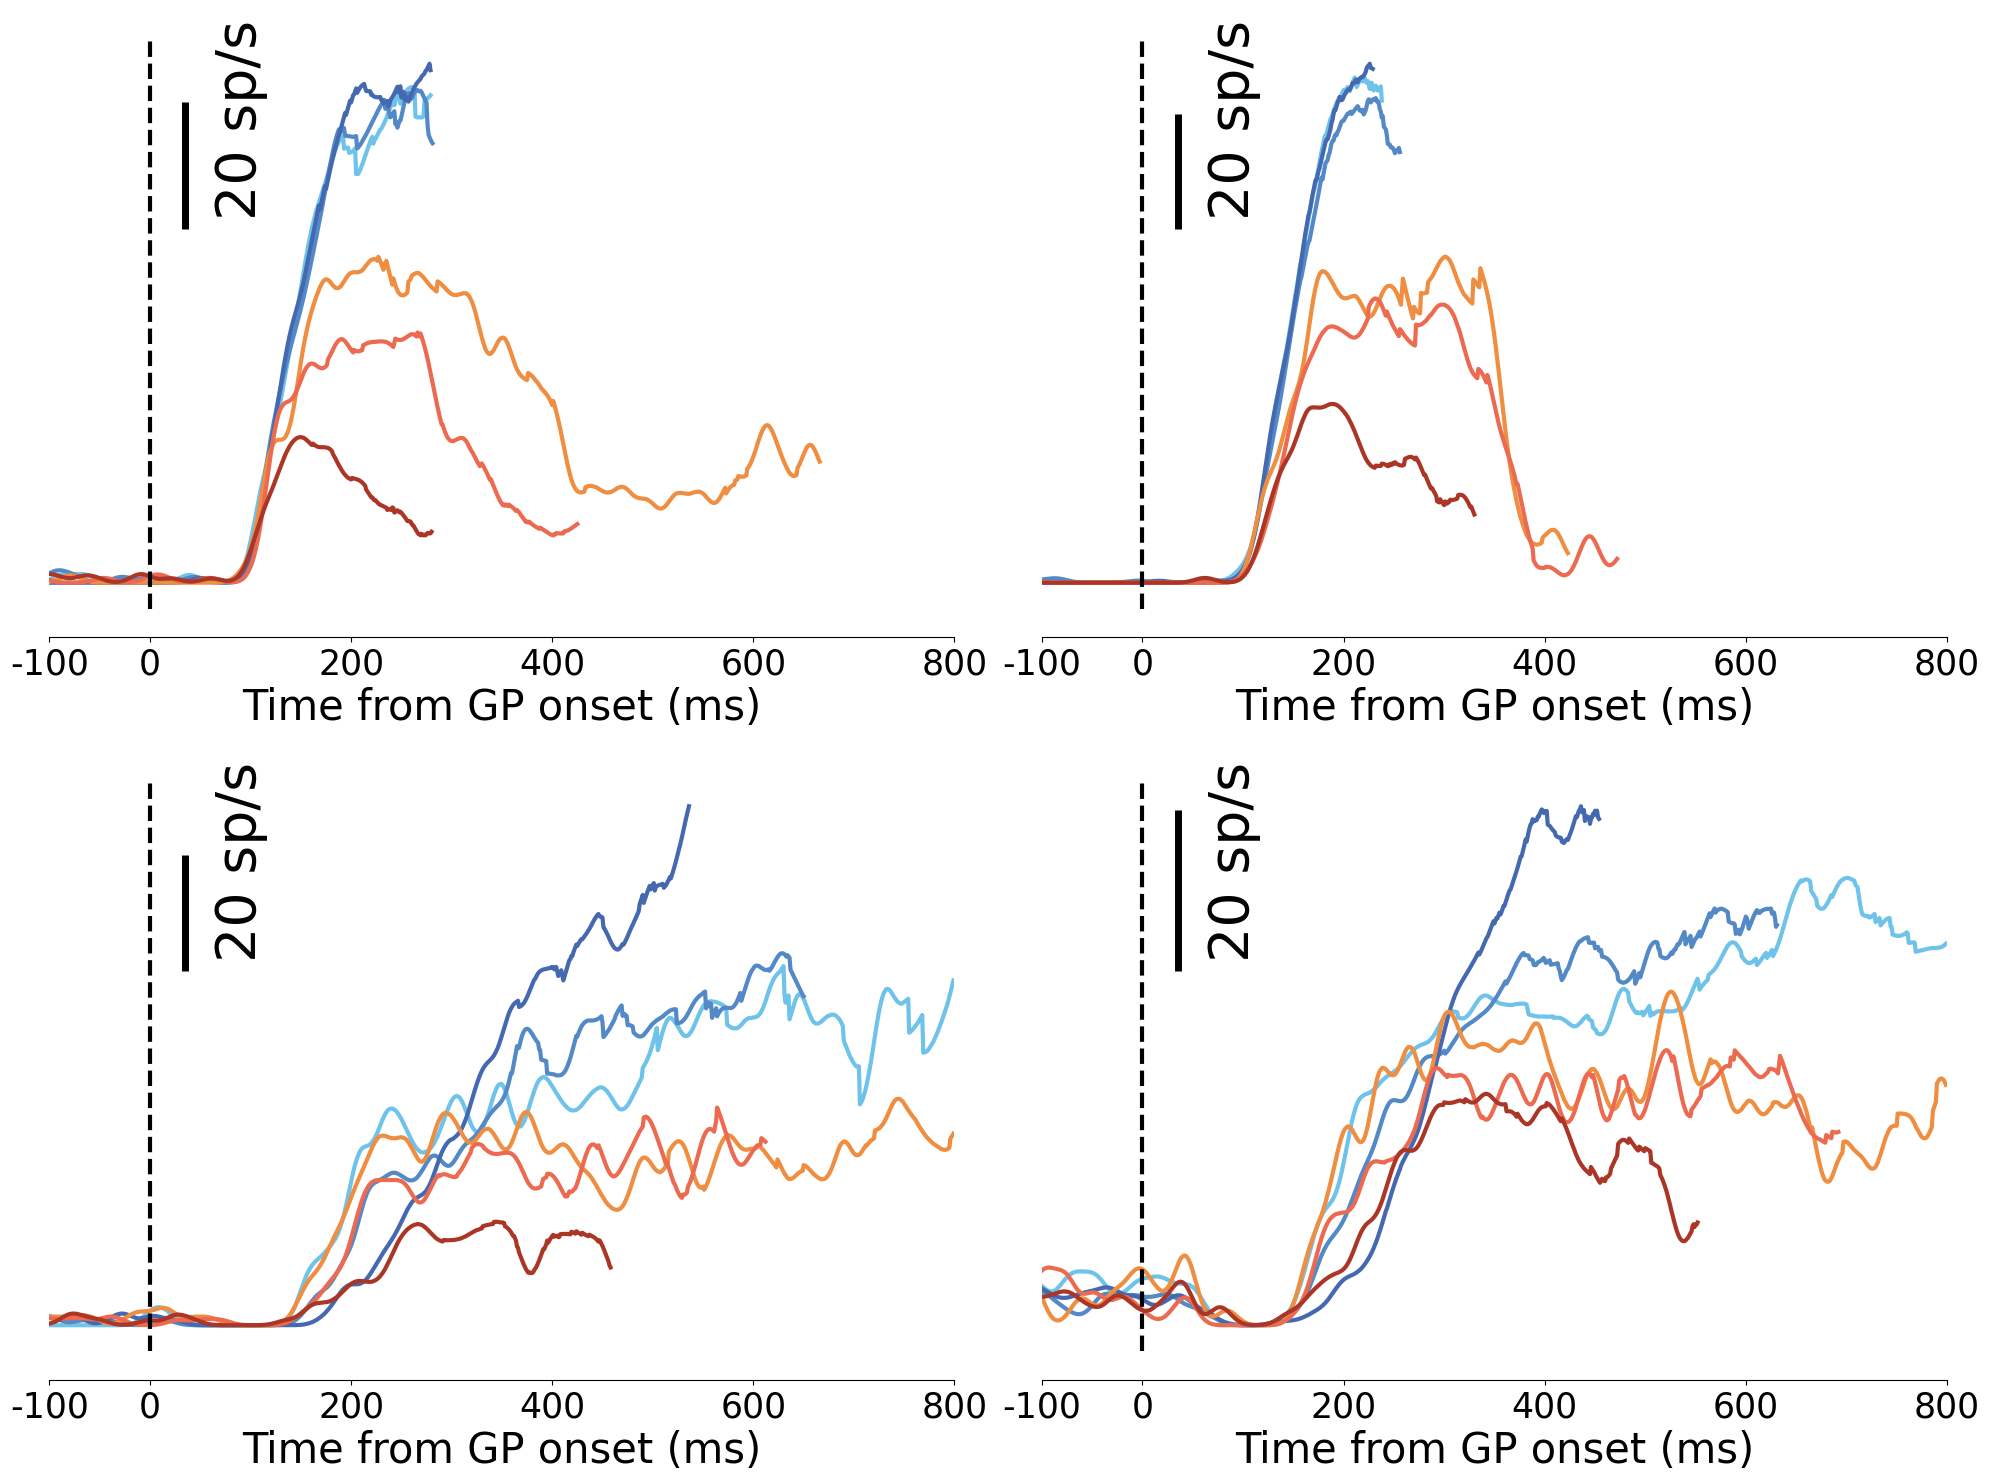

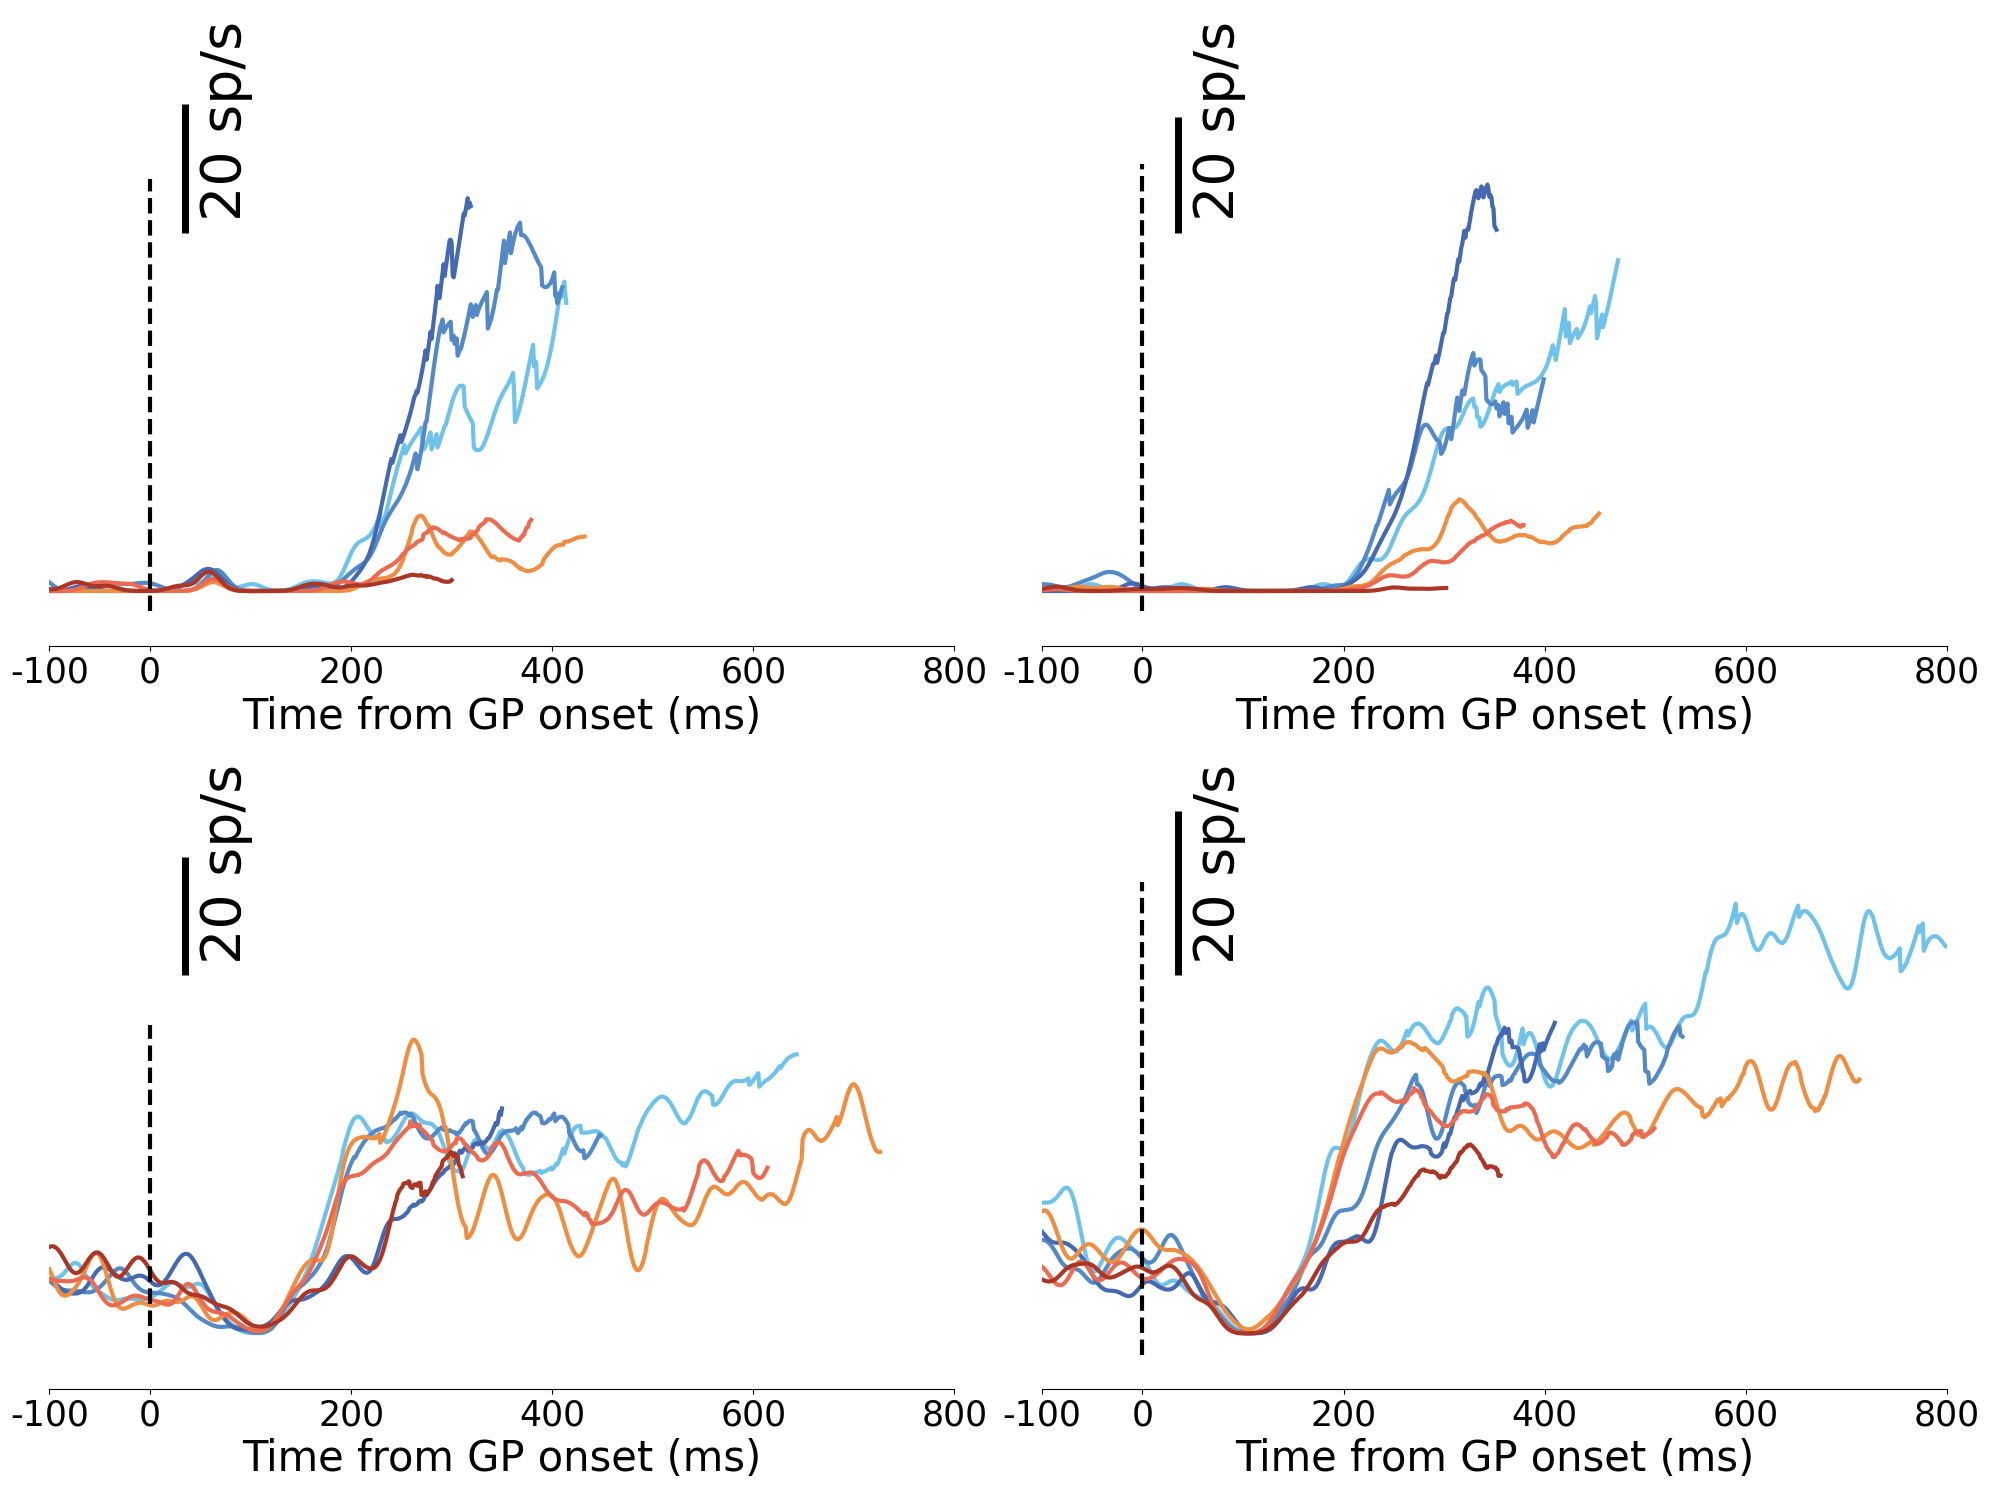

In [30]:
toRF_colors = ["#96D6EC", "#6FC3EB", "#5289C6", "#4469B1"]
unbiased_colors = ["#F2A448", "#EF8D41", "#EC6A50", "#AC3626"]

condition_dict = {
    "coh_0_choice_toRF_corr": {"index": 0, "color": {0:toRF_colors[0], 1: unbiased_colors[0]}, "lw": 3, "ls": '-'},
    "coh_6_choice_toRF_corr": {"index": 1, "color": {0:toRF_colors[1], 1: unbiased_colors[1]}, "lw": 3, "ls": '-'},
    "coh_20_choice_toRF_corr": {"index": 2, "color": {0:toRF_colors[2], 1: unbiased_colors[2]}, "lw": 3, "ls": '-'},
    "coh_50_choice_toRF_corr": {"index": 3, "color": {0:toRF_colors[3], 1: unbiased_colors[3]}, "lw": 3, "ls": '-'},
    "coh_0_choice_awayRF_corr": {"index": 4, "color": {0:toRF_colors[0], 1: unbiased_colors[0]}, "lw": 3, "ls": '-'},
    "coh_6_choice_awayRF_corr": {"index": 5, "color": {0:toRF_colors[1], 1: unbiased_colors[1]}, "lw": 3, "ls": '-'},
    "coh_20_choice_awayRF_corr": {"index": 6, "color": {0:toRF_colors[2], 1: unbiased_colors[2]}, "lw": 3, "ls": '-'},
    "coh_50_choice_awayRF_corr": {"index": 7, "color": {0:toRF_colors[3], 1: unbiased_colors[3]}, "lw": 3, "ls": '-'},
}
from copy import deepcopy

# --- Function to add scale bars ---
def add_scalebar(ax, plot_time=False, scalebar_x=200, scalebar_y=20, fontsize=40, additional_space=0.0):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    padding_x = 0.15 * (xlim[1] - xlim[0])
    padding_y = 0.35 * (ylim[1] - ylim[0])

    # Vertical bar (firing rate)
    x_start = xlim[0] + padding_x
    y_start = ylim[1] - padding_y
    ax.vlines(x_start, y_start, y_start + scalebar_y, color="black", linewidth=5)
    ax.text(x_start + padding_x/2 + additional_space, y_start + padding_y/2,
            f"{scalebar_y} sp/s", ha="right", va="center", fontsize=fontsize, rotation=90)


fig1, ax_1 = plt.subplots(2, 2, figsize=(20, 15))
ax_1 = ax_1.flatten()
fig2, ax_2 = plt.subplots(2, 2, figsize=(20, 15))
ax_2 = ax_2.flatten()


trial_info = deepcopy(data)
for neuron_idx, neuron in enumerate(included_neurons):
    session_id = neuron_metadata.session_id[neuron_metadata.neuron_id == neuron].values[0]
    trial_info[session_id] = trial_info[session_id][trial_info[session_id]["prob_toRF"] == 50]
    if neuron_idx >=2:
        plot_time=True
    else:
        plot_time=True

    if session_id not in session_metadata["session_id"].values:
        continue
    # plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_1[neuron_idx],plot_time=plot_time)
    if neuron_idx in [0,2]:
        plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_1[neuron_idx],plot_time=plot_time)
    elif neuron_idx in [1,3]:
        plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_2[neuron_idx-1],plot_time=plot_time)



# plt.savefig("spikedensity_toRF.svg", format="svg", dpi=300, bbox_inches="tight")


# plt.show()



trial_info = deepcopy(data)
for neuron_idx, neuron in enumerate(included_neurons):
    session_id = neuron_metadata.session_id[neuron_metadata.neuron_id == neuron].values[0]
    trial_info[session_id] = trial_info[session_id][trial_info[session_id]["prob_toRF"] != 50]

    if session_id not in session_metadata["session_id"].values:
        continue
    if neuron_idx in [0,2]:
        plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_1[neuron_idx+1],plot_time=plot_time)
    elif neuron_idx in [1,3]:
        plot_PSTH(neuron, condition_dict, alignment_dict=ephys_config["alignment_settings_GP"], ax=ax_2[neuron_idx],plot_time=plot_time)

# get max ylim across _1 nd _2
min_ylim = []
max_ylim = []
for i in range(4):
    min_ylim.append(min(ax_1[i].get_ylim()[0], ax_2[i].get_ylim()[0]))
    max_ylim.append(max(ax_1[i].get_ylim()[1], ax_2[i].get_ylim()[1]))

    ax_1[i].set_ylim(min_ylim[i], max_ylim[i])
    ax_2[i].set_ylim(min_ylim[i], max_ylim[i])

    add_scalebar(ax_1[i], plot_time=True, additional_space=15)
    add_scalebar(ax_2[i], plot_time=True)

# fig1 and fig2 tight layout
fig1.tight_layout()
fig2.tight_layout()

# save fig1 and fig2 separately
fig1.savefig("spikedensity_toRF.svg", format="svg", dpi=300, bbox_inches="tight")
fig2.savefig("spikedensity_awayRF.svg", format="svg", dpi=300, bbox_inches="tight")


# plt.savefig("spikedensity_awayRF.svg", format="svg", dpi=300, bbox_inches="tight")


plt.show()